# Milan mobile traffic — formative 1

**Comparative time series analysis and forecasting** of Telecom Italia (TIM) activity in Milan: real measurements over about two months on a **100×100** grid (10,000 areas).

---

## What this notebook covers

In this project, I analyzed mobile network traffic data from Milan, Italy. The data covers 62 days, has 10,000 grid squares, and records internet usage every 10 minutes. I completed three tasks: loading of data efficiently, exploring patterns through plots, and building three forecasting models to predict one week of traffic.

---

## Data used

**Telecom (62 daily `.txt` files)** — tab-separated rows. For this assignment only **three** fields are read from each line:

| Column index | Field | Role |
|--------------|--------|------|
| **0** | Square id | Grid cell (1 … 10,000) |
| **1** | Time | Unix time in **milliseconds** (10-minute steps) |
| **7** | Internet activity | CDR-based proxy for mobile data traffic |

Other columns (country code, SMS, calls) stay on disk and are **not** loaded into the analysis tables.

**Grid** — `milano-grid.geojson`: polygons and `cellId` for maps and spatial plots (mainly from Task 2 onward).

---



In [7]:
# standard libraries for paths, memory cleanup, and tabular I/O
import gc
from pathlib import Path

import numpy as np
import pandas as pd

In [8]:
# project root and locations of the telecom extract and Milan grid file
BASE = Path(r"c:\formative_1")

TELE_FOLDER = BASE / "Telecommunications - SMS, Call, Internet - MI"
GRID_FILE = BASE / "milano-grid" / "milano-grid.geojson"

print("="*30)
print("telecom folder exists:", TELE_FOLDER.is_dir())
print("grid file exists:", GRID_FILE.is_file())
print("="*30)

telecom folder exists: True
grid file exists: True


In [9]:
# full list of daily slices (one file per calendar day in the study period)
tele_files = sorted(TELE_FOLDER.glob("sms-call-internet-mi-*.txt"))
print("="*50)
print("number of day files:", len(tele_files))
print("first:", tele_files[0].name)
print("last:", tele_files[-1].name)
print("="*50)

number of day files: 62
first: sms-call-internet-mi-2013-11-01.txt
last: sms-call-internet-mi-2014-01-01.txt


In [10]:
# verify raw line layout — 8 fields per row; assignment uses cols 0, 1, 7
sample_path = tele_files[0]
raw = pd.read_csv(sample_path, sep="\t", header=None, nrows=5)
print("="*80)
print("raw shape (5 rows):", raw.shape)
print(raw)
print("="*80)

raw shape (5 rows): (5, 8)
   0              1   2         3         4         5         6          7
0  1  1383260400000   0  0.081363       NaN       NaN       NaN        NaN
1  1  1383260400000  39  0.141864  0.156787  0.160938  0.052275  11.028366
2  1  1383261000000   0  0.136588       NaN       NaN  0.027300        NaN
3  1  1383261000000  33       NaN       NaN       NaN       NaN   0.026137
4  1  1383261000000  39  0.278452  0.119926  0.188777  0.133637  11.100963


In [ ]:
# Calculate memory usage of a dataframe in megabytes
# deep=True ensures string columns are counted accurately
def df_mb(df):
    return df.memory_usage(deep=True).sum() / 1e6

In [12]:
# same row count both sides — MB numbers are representative of dtype/column savings at full scale
N = 200_000
path = tele_files[0]

# Baseline: full row width as stored in the files (all 8 fields, default dtypes)
df_big = pd.read_csv(path, sep="\t", header=None, nrows=N)
mem_before = df_mb(df_big)
print("="*50)
print("BEFORE — all columns, default dtypes")
print("  rows:", len(df_big), "cols:", df_big.shape[1])
print("  memory MB:", round(mem_before, 2))
del df_big
gc.collect()

# Optimized slice: only fields required by the brief; compact numeric dtypes
df_small = pd.read_csv(
    path,
    sep="\t",
    header=None,
    usecols=[0, 1, 7],
    nrows=N,
    names=["square_id", "time_ms", "internet"],
)
df_small["square_id"] = df_small["square_id"].astype(np.uint16)
df_small["internet"] = df_small["internet"].astype(np.float32)

print("="*50)

mem_after = df_mb(df_small)
print("AFTER — square, time, internet only + uint16/float32")
print("  rows:", len(df_small), "cols:", df_small.shape[1])
print("  memory MB:", round(mem_after, 2))
print("  about", round(mem_before / mem_after, 1), "x less RAM for this slice")
print("="*50)

BEFORE — all columns, default dtypes
  rows: 200000 cols: 8
  memory MB: 12.8
AFTER — square, time, internet only + uint16/float32
  rows: 200000 cols: 3
  memory MB: 2.8
  about 4.6 x less RAM for this slice


In [ ]:
# Read one day file in small chunks to avoid running out of memory
# Each chunk is 400,000 rows - process it, then discard before reading next chunk

def read_day_internet(path, chunksize=400_000):
    """Stream a single day file as square_id, time_ms, internet with compact dtypes."""
    reader = pd.read_csv(
        path,
        sep="\t",
        header=None,
        usecols=[0, 1, 7],
        names=["square_id", "time_ms", "internet"],
        chunksize=chunksize,
    )
    for chunk in reader:
        chunk["square_id"] = chunk["square_id"].astype(np.uint16)
        chunk["internet"] = chunk["internet"].astype(np.float32)
        yield chunk


# Test the chunk reader on the first day file
# Calculate total traffic per square without loading the whole file into RAM
path = tele_files[0]
totals = None
for ch in read_day_internet(path):
    g = ch.groupby("square_id", sort=False)["internet"].sum()
    if totals is None:
        totals = g
    else:
        totals = totals.add(g, fill_value=0)

print("="*50)
print("one day done. unique squares:", totals.index.size)
print("top 3 busy squares that day:", totals.nlargest(3).head())
print("="*50)

one day done. unique squares: 10000
top 3 busy squares that day: square_id
5161    237230.390625
5059    160148.765625
5758    127441.023438
Name: internet, dtype: float32


In [14]:
# hardware and software (brief asks for setup + limitations)
import os
import platform
import sys

print("=== environment ===")
print("machine:", platform.machine())
proc = platform.processor()
print("processor:", proc if proc else "(not exposed by OS)")
print("system:", platform.system(), platform.release())
print("python:", sys.version.split()[0])
print("executable:", sys.executable)
print("pandas:", pd.__version__, "| numpy:", np.__version__)
print("logical CPUs:", os.cpu_count())

try:
    import psutil

    m = psutil.virtual_memory()
    print("RAM total (approx):", round(m.total / (1024**3), 2), "GB")
    print("RAM available now (approx):", round(m.available / (1024**3), 2), "GB")
except ModuleNotFoundError:
    print("RAM: not printed (optional: pip install psutil). Note total RAM from Task Manager for the PDF.")

print()
print("Design limitation addressed here: ~5 GB on disk across 62 days;")
print("peak RAM is kept bounded using chunks + usecols + smaller dtypes (see above).")

=== environment ===
machine: AMD64
processor: Intel64 Family 6 Model 166 Stepping 1, GenuineIntel
system: Windows 11
python: 3.13.13
executable: c:\formative_1\.venv\Scripts\python.exe
pandas: 3.0.3 | numpy: 2.4.4
logical CPUs: 8
RAM total (approx): 15.78 GB
RAM available now (approx): 3.15 GB

Design limitation addressed here: ~5 GB on disk across 62 days;
peak RAM is kept bounded using chunks + usecols + smaller dtypes (see above).


---

## Task 2 - Exploratory data analysis

Characterise Milan internet traffic: city-wide totals per square, time patterns in three areas, stationarity, seasonality, ACF/PACF, spatial heatmap, and unusual points.


In [15]:
# Task 2: plotting and time-series tools
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

PROCESSED = BASE / "processed"
PROCESSED.mkdir(exist_ok=True)

In [ ]:
# Sum internet per square over all 62 days. Save to CSV after first run.
# Next run, it should load from CSV instead of reprocessing 5GB of data.
# The goal is to find the busiest square from all the 10,000 squares

TOTALS_FILE = PROCESSED / "square_totals_2mo.csv"


def build_square_totals(files):
    totals = None
    for i, path in enumerate(files, start=1):
        for ch in read_day_internet(path):
            g = ch.groupby("square_id", sort=False)["internet"].sum()
            totals = g if totals is None else totals.add(g, fill_value=0)
        if i % 10 == 0 or i == len(files):
            print(f"  processed {i}/{len(files)} days")
    return totals.sort_index()

# Load from cache if available, otherwise build from scratch
if TOTALS_FILE.is_file():
    square_totals = pd.read_csv(TOTALS_FILE, index_col="square_id")["internet"]
    print("loaded cached totals:", TOTALS_FILE.name)
else:
    print("building totals over all days (one-time)...")
    square_totals = build_square_totals(tele_files)
    square_totals.to_csv(TOTALS_FILE, header=["internet"])
    print("saved:", TOTALS_FILE)

print("squares:", len(square_totals))
top_square = int(square_totals.idxmax())
print("busiest square (2 months):", top_square, "| total:", round(float(square_totals.max()), 1))

loaded cached totals: square_totals_2mo.csv
squares: 10000
busiest square (2 months): 5161 | total: 12740060.0


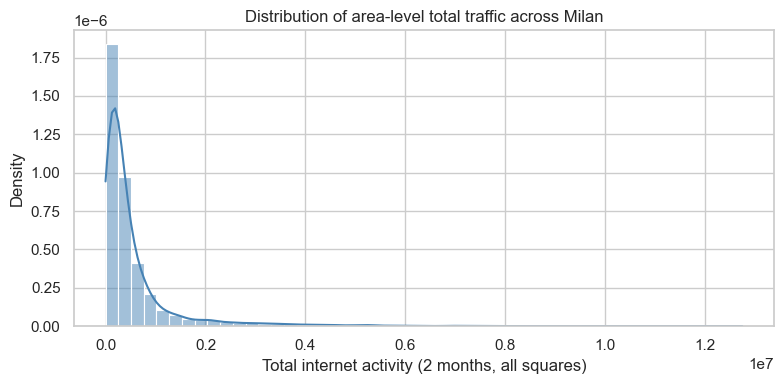

mean: 555289.4 | median: 277871.1
min: 213.6 | max: 12740060.0
top 1% threshold: 4698731.6


In [ ]:
# PROBABILITY DENSITY FUNCTION (PDF) PLOT
# Show how total traffic is distributed across all 10,000 squares


# Get the total traffic values for all 10,000 squares
vals = square_totals.values.astype(float)

# Create histogram with density curve (KDE)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(vals, stat="density", kde=True, bins=50, ax=ax, color="steelblue")
ax.set_xlabel("Total internet activity (2 months, all squares)")
ax.set_ylabel("Density")
ax.set_title("Distribution of area-level total traffic across Milan")
plt.tight_layout()
plt.show()

# Print summary statistics
print("mean:", round(vals.mean(), 1), "| median:", round(np.median(vals), 1))
print("min:", round(vals.min(), 1), "| max:", round(vals.max(), 1))
print("top 1% threshold:", round(np.percentile(vals, 99), 1))

### For the PDF plot,

The distribution is **strongly right-skewed**: most squares have **moderate** total traffic, while a **small tail** reaches much higher values (busy centres, stations, nightlife). That is **not homogeneous** — Milan mixes quiet residential cells with hotspots. Physically, CDR counts rise where many people use mobile data (city centre, transport hubs, events), so a few grid cells dominate the upper tail while thousands stay low.

In [ ]:
# PREPARE TIME SERIES DATA FOR THE FIRST TWO WEEKS
# I to build 10-minute traffic data for three squares (Nov 1-14)
# three squares — busiest over 2 months which is 5161, plus 4159 and 4556


# Define the three squares 
SQUARE_A = top_square
SQUARE_B = 4159
SQUARE_C = 4556
PLOT_SQUARES = [SQUARE_A, SQUARE_B, SQUARE_C]
LABELS = {SQUARE_A: f"busiest ({SQUARE_A})", SQUARE_B: "id 4159", SQUARE_C: "id 4556"}

# First two weeks = first 14 daily files (Nov 1 to Nov 14, 2013)
# Save it into a CSV file
files_2weeks = tele_files[:14]
TS_2W_FILE = PROCESSED / "ts_2weeks_3squares.csv"


def build_ts_for_squares(square_ids, files):
    """10-minute series per square: sum internet per (square, time)."""
    want = set(square_ids)
    parts = []
    for path in files:
        for ch in read_day_internet(path):
            sub = ch[ch["square_id"].isin(want)]
            if sub.empty:
                continue
            g = sub.groupby(["square_id", "time_ms"], sort=False)["internet"].sum()
            parts.append(g)
    if not parts:
        return pd.DataFrame(columns=["square_id", "time_ms", "internet", "time"])
    out = pd.concat(parts).groupby(level=[0, 1], sort=False).sum().reset_index()
    out.columns = ["square_id", "time_ms", "internet"]
    out["time"] = pd.to_datetime(out["time_ms"], unit="ms", utc=True).dt.tz_convert(None)
    return out


# Load from cache if available, otherwise build from scratch
if TS_2W_FILE.is_file():
    ts_2w = pd.read_csv(TS_2W_FILE, parse_dates=["time"])
    print("loaded cached 2-week series:", TS_2W_FILE.name)
else:
    print("building 2-week series for 3 squares...")
    ts_2w = build_ts_for_squares(PLOT_SQUARES, files_2weeks)
    ts_2w.to_csv(TS_2W_FILE, index=False)
    print("saved:", TS_2W_FILE)


# extract one square's data as a time series, to help me plot each square alone
def to_series(df, sid):
    s = df.loc[df["square_id"] == sid].set_index("time")["internet"].sort_index()
    return s.astype(float)

loaded cached 2-week series: ts_2weeks_3squares.csv


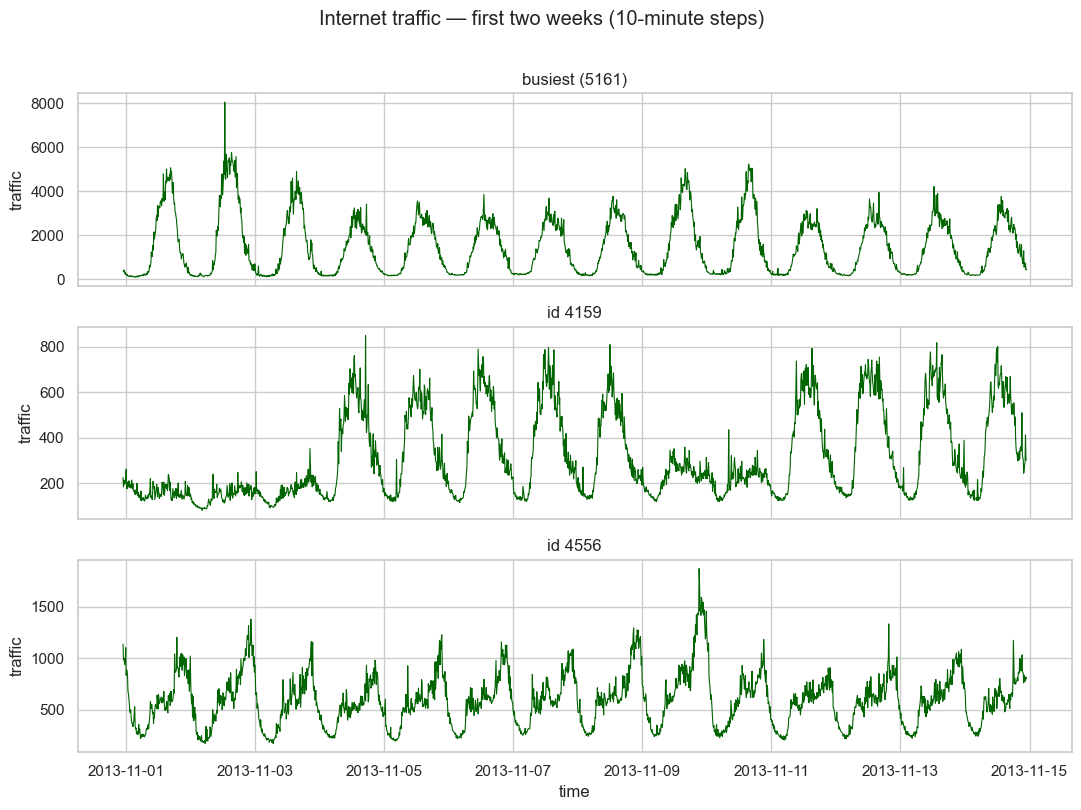

In [19]:
#  plot first two weeks for the three areas
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

for ax, sid in zip(axes, PLOT_SQUARES):
    s = to_series(ts_2w, sid)
    ax.plot(s.index, s.values, linewidth=0.8, color="darkgreen")
    ax.set_ylabel("traffic")
    ax.set_title(LABELS[sid])

axes[-1].set_xlabel("time")
fig.suptitle("Internet traffic — first two weeks (10-minute steps)", y=1.01)
plt.tight_layout()
plt.show()

All three series show a **clear daily rhythm** (peaks in daytime, lower at night) and **weekly structure** (weekend vs weekday shapes differ). The **busiest** square has the **largest amplitude** likely a central or highly visited zone. **4159** and **4556** are lower overall but still periodic; differences in level and peak timing may reflect land use (office vs residential vs mixed). Short spikes can be local crowding or routing effects in the mobile network, not only “more users”.

In [ ]:
# full-period series for the busiest square (stationarity, decompose, ACF)
# Build 2-month time series for square 5161 (busiest square)

# Cache file for the busiest square's full time series
TS_FULL_FILE = PROCESSED / f"ts_full_square_{top_square}.csv"

# Load from cache if available (fast), otherwise build from all 62 files (slow)
if TS_FULL_FILE.is_file():
    ts_full = pd.read_csv(TS_FULL_FILE, parse_dates=["time"])
    print("loaded:", TS_FULL_FILE.name)
else:
    print("building full series for square", top_square, "(all days)...")
    ts_full = build_ts_for_squares([top_square], tele_files)
    ts_full.to_csv(TS_FULL_FILE, index=False)

# Extract as time-indexed Series for easier analysis
s_main = to_series(ts_full, top_square)

# Convert to regular 10-minute grid (fills missing gaps with 0)
# This ensures exactly 144 points per day, needed for decomposition
s_reg = s_main.resample("10min").sum().fillna(0)
print("points:", len(s_reg), "| from", s_reg.index.min(), "to", s_reg.index.max())

loaded: ts_full_square_5161.csv
points: 8928 | from 2013-10-31 23:00:00 to 2014-01-01 22:50:00


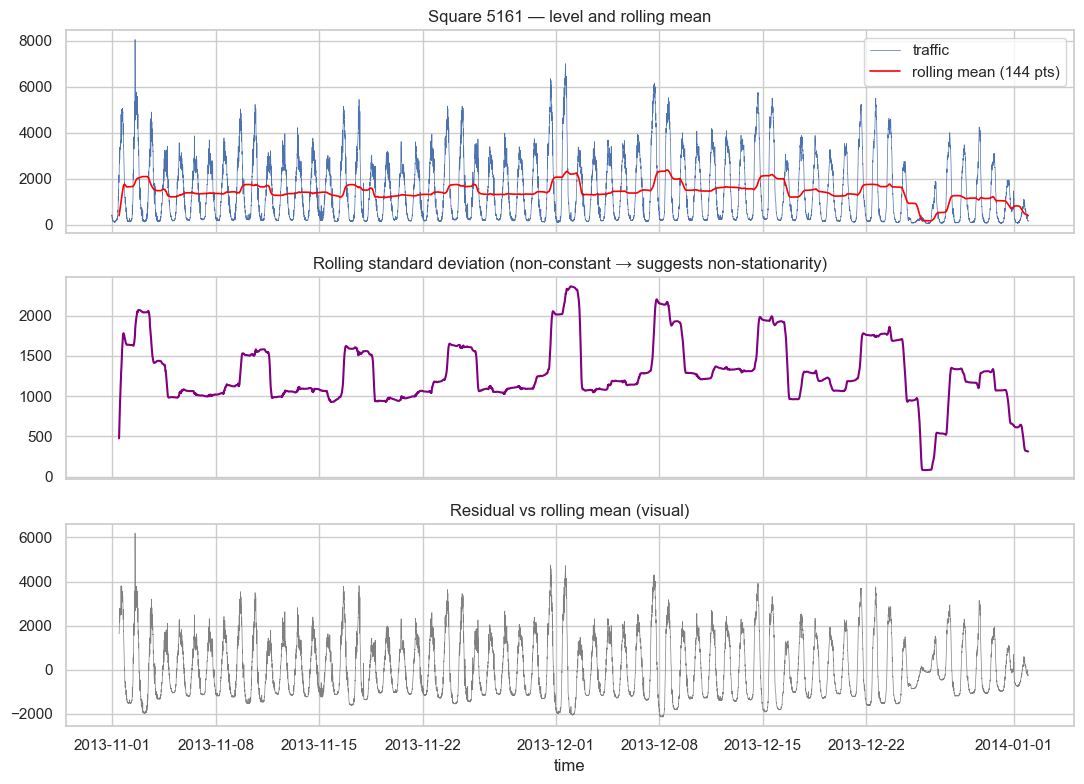

ADF statistic: -19.0319
p-value: 0.0
critical values: {'1%': np.float64(-3.431), '5%': np.float64(-2.862), '10%': np.float64(-2.567)}
→ reject H0 at 5%: evidence the series is stationary (in ADF sense).


In [ ]:
# Test if the time series has a unit root (non-stationary)
# Method 1: Visual check using rolling mean and rolling standard deviation
# Method 2: Statistical test using Augmented Dickey-Fuller (ADF)


# Rolling window = 144 points (one full day at 10-minute intervals)
# This shows how the average and variance change over time
win = 144
roll_mean = s_reg.rolling(win, min_periods=win // 2).mean()
roll_std = s_reg.rolling(win, min_periods=win // 2).std()

# Create three plots stacked vertically
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

# Plot 1: Original traffic with rolling mean (red line)
axes[0].plot(s_reg.index, s_reg.values, linewidth=0.5, label="traffic")
axes[0].plot(roll_mean.index, roll_mean.values, color="red", linewidth=1.2, label=f"rolling mean ({win} pts)")
axes[0].legend(loc="upper right")
axes[0].set_title(f"Square {top_square} — level and rolling mean")

# Plot 2: Rolling standard deviation (should be constant for stationary series)
axes[1].plot(roll_std.index, roll_std.values, color="purple")
axes[1].set_title("Rolling standard deviation (non-constant → suggests non-stationarity)")

# Plot 3: Residual (traffic minus rolling mean) - shows variation around average
axes[2].plot(s_reg.index, s_reg.values - roll_mean.values, linewidth=0.5, color="gray")
axes[2].set_title("Residual vs rolling mean (visual)")
axes[2].set_xlabel("time")
plt.tight_layout()
plt.show()

# Augmented Dickey–Fuller test (H0: unit root / non-stationary)
adf_stat, adf_p, used_lag, nobs, crit, icbest = adfuller(s_reg.values, autolag="AIC")
print("ADF statistic:", round(adf_stat, 4))
print("p-value:", round(adf_p, 4))
print("critical values:", {k: round(v, 3) for k, v in crit.items()})
if adf_p < 0.05:
    print("→ reject H0 at 5%: evidence the series is stationary (in ADF sense).")
else:
    print("→ do not reject H0: series behaves non-stationary; differencing may help for models.")

Rolling mean and std **move over time** (especially mean level and variance across weeks), which is typical of **traffic with trend and seasonality**. The **ADF** result should be read together with the plots: even if the test rejects non-stationarity, **visible daily cycles** mean models often still use **differencing or seasonal terms**. For forecasting (Task 3), treating strong **daily seasonality** explicitly is usually better than assuming a flat stationary process.

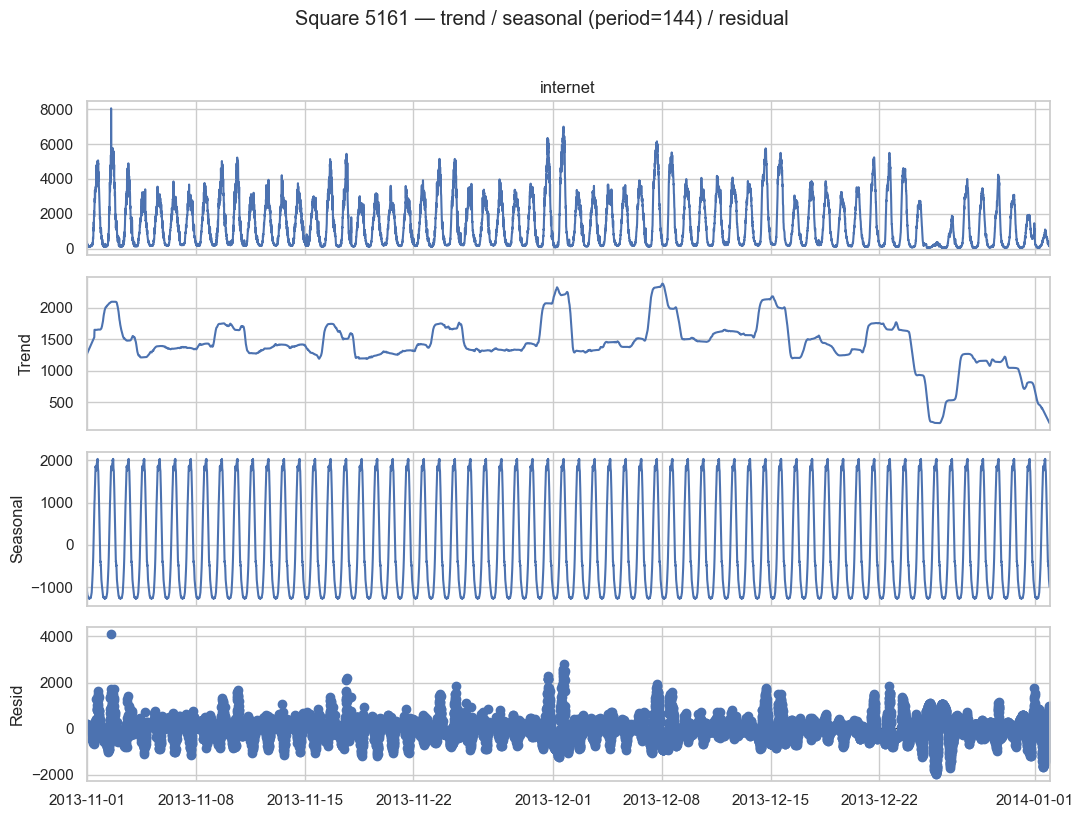

In [22]:
# seasonal decomposition — daily period at 10-minute steps (144 points per day)
period = 144
# use a contiguous slice so statsmodels is happy (no long NaN gaps)
s_dec = s_reg.dropna()
decomp = seasonal_decompose(s_dec, model="additive", period=period, extrapolate_trend="freq")

fig = decomp.plot()
fig.set_size_inches(11, 8)
fig.suptitle(f"Square {top_square} — trend / seasonal (period={period}) / residual", y=1.02)
plt.tight_layout()
plt.show()

The **seasonal** component repeats about every **24 hours** (144 × 10 min), matching **human activity**: higher traffic by day, lower at night. The **trend** drifts slowly over weeks (holidays, weather, gradual behaviour change). **Residuals** hold what is not explained — short bursts, noise, and events. That daily period is the main pattern Task 3 models should respect.

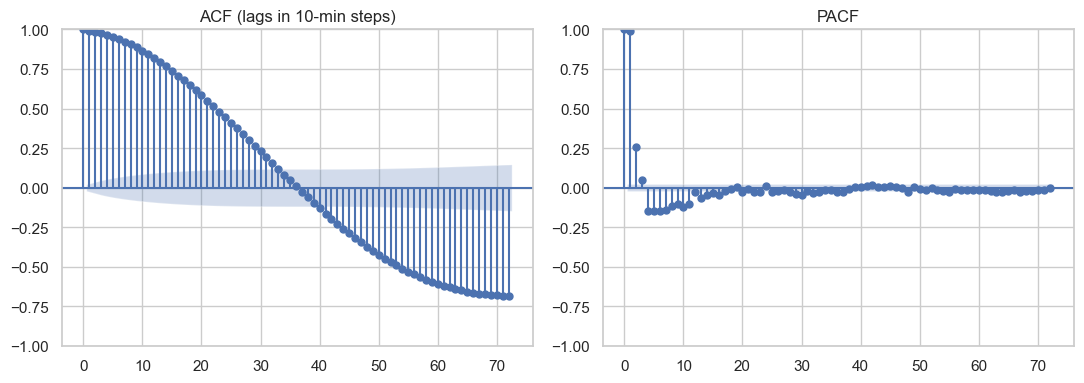

In [23]:
# ACF and PACF — how past values relate to the present
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_acf(s_reg.values, lags=72, ax=axes[0], alpha=0.05)  # up to 12 hours back
axes[0].set_title("ACF (lags in 10-min steps)")

plot_pacf(s_reg.values, lags=72, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

### ACF and PACF summary

**ACF** stays high for many lags because **daily seasonality** repeats, values 24 h apart are alike. Spikes near lag **144** (one day) and **288** (two days) point to **strong day-to-day structure**. **PACF** is sharper at short lags: the **last few 10-minute bins** carry direct predictive information before seasonality dominates. That supports lag-based or seasonal models in Task 3.

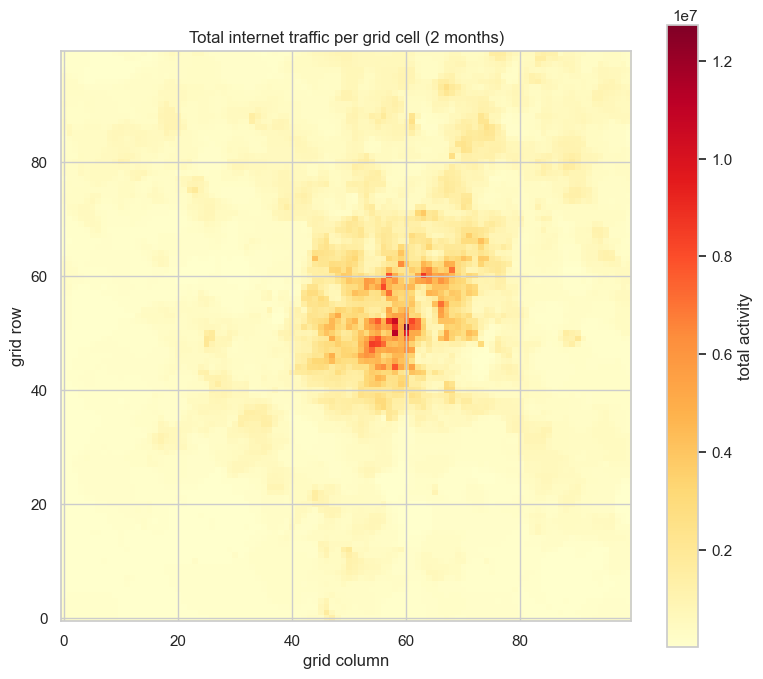

In [24]:
# spatial heatmap — total two-month traffic on the 100×100 grid
grid = np.zeros((100, 100), dtype=float)
for sid, val in square_totals.items():
    sid = int(sid)
    # cellId 1 … 10000 maps to row-major cells in the Milan grid
    r = (sid - 1) // 100
    c = (sid - 1) % 100
    grid[r, c] = float(val)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(grid, origin="lower", cmap="YlOrRd", aspect="equal")
ax.set_title("Total internet traffic per grid cell (2 months)")
ax.set_xlabel("grid column")
ax.set_ylabel("grid row")
plt.colorbar(im, ax=ax, label="total activity")
plt.tight_layout()
plt.show()

### spatial heatmap summary

Traffic is **not uniform in space**: a **dense hotspot** (bright area) sits in the **urban core**, while suburbs and edge cells stay pale. That matches **where people work, shop, and travel** in Milan. The grid is a coarse proxy, but the map shows **spatial concentration** 

### Anomalies and outliers

- **Distribution tail (I):** a few squares with extreme totals vs the bulk, likely **landmarks, stations, Duomo area**, not measurement errors alone.  
- **Time spikes (II):** short upward jumps above the daily wave, possible **events, concerts, football**, or **commute peaks**.  
- **Zeros / gaps:** empty CDR bins read as **0** after resampling; can be **no activity** or **missing reports**, not always true zero demand.  
- **December holidays:** late-month levels can **dip** when people leave the city, visible in trend/residual (IV).  
- **Single-day build (Task 1 demo):** busiest square **5161** on one day may differ slightly from **two-month** top square, always use the **full-period** total for Task 3 area choice.

These patterns matter for Task 3: models that only see smooth seasonality may **fail on spike days** 

---

## Task 3 — Forecasting

**Goal:** one-step-ahead internet traffic at one square, using past values only.

**Areas to build model for:** busiest square **5161**, plus **4159** and **4556**.

**Test week (never used for training):** **16–22 December 2013**.

**First Model:**
1. **Model 1** — Lag linear regression (OLS) 


In [25]:
# libraries and requirements
import time

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Using the same squares as the one of task 2
FORECAST_SQUARES = [5161, 4159, 4556]

# test week only (training uses everything before this)
TEST_START = pd.Timestamp("2013-12-16")
TEST_END = pd.Timestamp("2013-12-23")  # exclusive → includes all of 22 Dec

# past values used to predict the next 10-minute step
LAGS = [1, 2, 3, 144]  # 144 = same time yesterday (Task 2 daily period)

In [26]:
# load one square as a regular 10-minute series (builds file if missing)
def get_regular_series(square_id):
    path = PROCESSED / f"ts_full_square_{square_id}.csv"
    if not path.is_file():
        print("building full series for square", square_id)
        df = build_ts_for_squares([square_id], tele_files)
        df.to_csv(path, index=False)
    df = pd.read_csv(path, parse_dates=["time"])
    s = df.set_index("time")["internet"].astype(float)
    s = s.resample("10min").sum().fillna(0)
    return s.sort_index()

In [27]:
# split train / test by date
def split_train_test(s):
    train = s[s.index < TEST_START]
    test = s[(s.index >= TEST_START) & (s.index < TEST_END)]
    return train, test

In [28]:
# error metrics for the test week
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

### Model 1: Linear Regression with Lag Features
**Type:** Classical statistical model (Linear Regression).

**Input:** Traffic values from lags 1, 2, 3 (past 30 minutes) and lag 144 (same time yesterday).

**Preprocessing:**Scaled features using StandardScaler. Fitted on training data only.

**Training:** All data before December 16, 2013. Target is the next 10-minute traffic value.

**Prediction:** One-step-ahead for December 16-22. Used true past values for each prediction.

In [29]:
# Model 1: build training matrix from a series
def make_train_xy(series, lags):
    max_lag = max(lags)
    X, y = [], []
    for i in range(max_lag, len(series) - 1):
        row = [series.iloc[i - lag] for lag in lags]
        X.append(row)
        y.append(series.iloc[i + 1])
    return np.array(X, dtype=float), np.array(y, dtype=float)

In [30]:
# Model 1: one-step-ahead predictions on the test week
def predict_one_step(train, test, model, scaler, lags):
    full = pd.concat([train, test])
    n_train = len(train)
    preds = []
    for i in range(len(test)):
        idx = n_train + i - 1
        row = np.array([[full.iloc[idx - lag] for lag in lags]])
        row = scaler.transform(row)
        preds.append(model.predict(row)[0])
    return np.array(preds)

In [31]:
# Model 1: train + predict for all three squares and keep the results
m1_preds = {}
m1_metrics = {}
m1_train_sec = {}
m1_predict_sec = {}

for sid in FORECAST_SQUARES:
    s = get_regular_series(sid)
    train, test = split_train_test(s)
    print(f"square {sid}: train={len(train)}, test={len(test)}")

    X_train, y_train = make_train_xy(train, LAGS)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)

    model = LinearRegression()

    t0 = time.perf_counter()
    model.fit(X_train_s, y_train)
    m1_train_sec[sid] = time.perf_counter() - t0

    t0 = time.perf_counter()
    pred = predict_one_step(train, test, model, scaler, LAGS)
    m1_predict_sec[sid] = time.perf_counter() - t0

    y_true = test.values
    m1_preds[sid] = (test.index, y_true, pred)
    m1_metrics[sid] = {
        "MAE": mae(y_true, pred),
        "MAPE": mape(y_true, pred),
        "RMSE": rmse(y_true, pred),
    }

print("Model 1 metrics:")
for sid in FORECAST_SQUARES:
    print(sid, m1_metrics[sid])
print("train time (s):", m1_train_sec)
print("predict time (s):", m1_predict_sec)

square 5161: train=6486, test=1008
square 4159: train=6486, test=1008
square 4556: train=6486, test=1008
Model 1 metrics:
5161 {'MAE': np.float64(140.47707483839403), 'MAPE': np.float64(13.81502890722081), 'RMSE': np.float64(199.80936519074604)}
4159 {'MAE': np.float64(18.794232448730718), 'MAPE': np.float64(8.294948881306487), 'RMSE': np.float64(25.097450886510156)}
4556 {'MAE': np.float64(33.661665572847205), 'MAPE': np.float64(8.020964196939897), 'RMSE': np.float64(43.966270593359525)}
train time (s): {5161: 0.0014393000165000558, 4159: 0.0010287999757565558, 4556: 0.000980700016953051}
predict time (s): {5161: 0.2459489000029862, 4159: 0.2141074999817647, 4556: 0.22594030003529042}


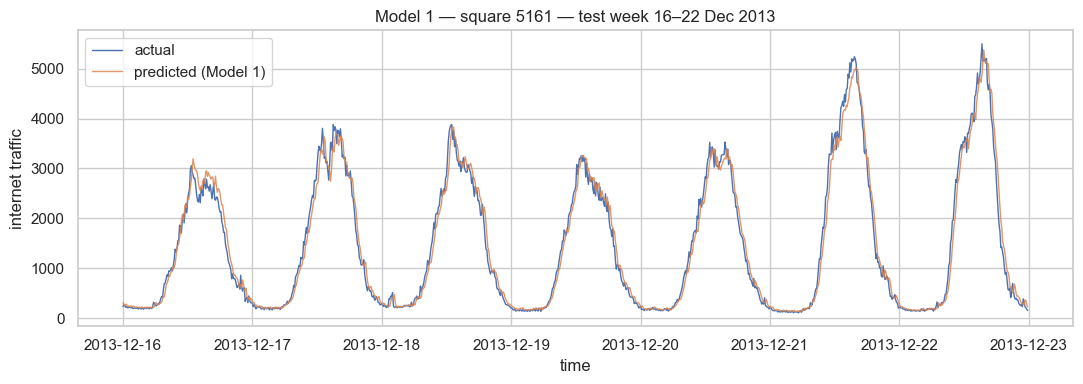

In [32]:
# Model 1 — plot: square 5161 (busiest)
sid = 5161
idx, y_true, pred = m1_preds[sid]

plt.figure(figsize=(11, 4))
plt.plot(idx, y_true, label="actual", linewidth=1)
plt.plot(idx, pred, label="predicted (Model 1)", linewidth=1, alpha=0.85)
plt.title(f"Model 1 — square {sid} — test week 16–22 Dec 2013")
plt.xlabel("time")
plt.ylabel("internet traffic")
plt.legend()
plt.tight_layout()
plt.show()

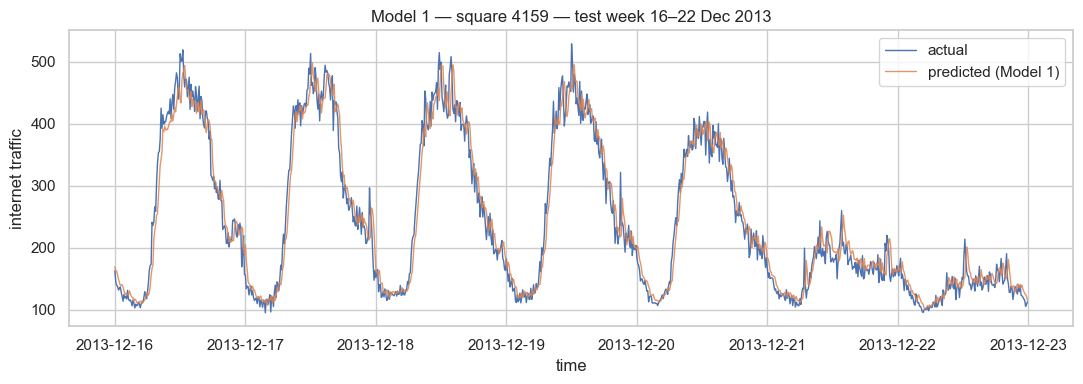

In [33]:
# Model 1 — plot: square 4159
sid = 4159
idx, y_true, pred = m1_preds[sid]

plt.figure(figsize=(11, 4))
plt.plot(idx, y_true, label="actual", linewidth=1)
plt.plot(idx, pred, label="predicted (Model 1)", linewidth=1, alpha=0.85)
plt.title(f"Model 1 — square {sid} — test week 16–22 Dec 2013")
plt.xlabel("time")
plt.ylabel("internet traffic")
plt.legend()
plt.tight_layout()
plt.show()

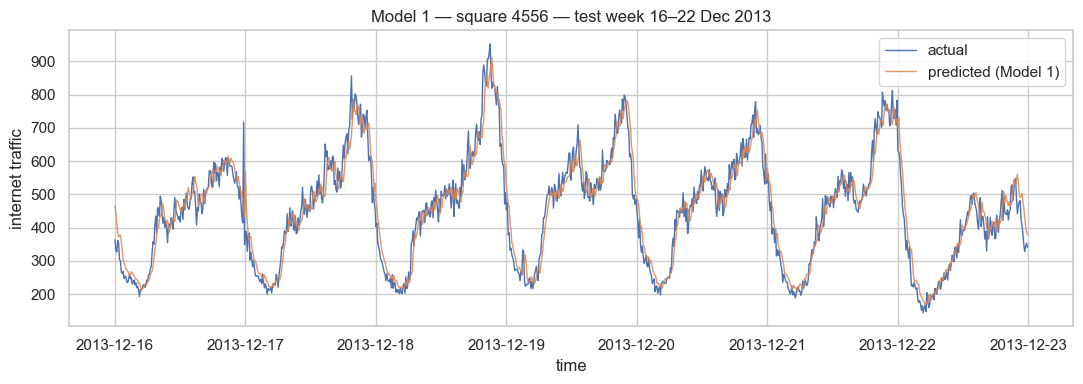

In [34]:
# Model 1 — plot: square 4556
sid = 4556
idx, y_true, pred = m1_preds[sid]

plt.figure(figsize=(11, 4))
plt.plot(idx, y_true, label="actual", linewidth=1)
plt.plot(idx, pred, label="predicted (Model 1)", linewidth=1, alpha=0.85)
plt.title(f"Model 1 — square {sid} — test week 16–22 Dec 2013")
plt.xlabel("time")
plt.ylabel("internet traffic")
plt.legend()
plt.tight_layout()
plt.show()

### Model 2 — Long Short-Term Memory 




In [35]:
# Model 2 — settings
LOOKBACK = 144
EPOCHS = 30
BATCH = 64
PATIENCE = 4

print("=" * 50)
print("MODEL 2 — LSTM SETTINGS")
print("=" * 50)
print("lookback steps:", LOOKBACK)
print("max epochs:", EPOCHS)
print("batch size:", BATCH)
print("early-stop patience:", PATIENCE)
print("=" * 50)


MODEL 2 — LSTM SETTINGS
lookback steps: 144
max epochs: 30
batch size: 64
early-stop patience: 4


In [36]:
# Step 1 — import tensorflow / keras
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Input, LSTM
from tensorflow.keras.models import Sequential

import tensorflow as tf

print("=" * 50)
print("STEP 1 DONE — TensorFlow", tf.__version__)
print("=" * 50)


STEP 1 DONE — TensorFlow 2.21.0


In [37]:
# make_lstm_xy
def make_lstm_xy(scaled_1d, lookback):
    X, y = [], []
    for i in range(lookback, len(scaled_1d)):
        X.append(scaled_1d[i - lookback : i])
        y.append(scaled_1d[i])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y

print("=" * 50)
print("make_lstm_xy defined")
print("=" * 50)


make_lstm_xy defined


In [38]:
# scale the data (fit on train only)
def scale_train_series(train_series):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(
        train_series.values.reshape(-1, 1)
    ).flatten()
    return scaler, scaled

print("=" * 50)
print("scale_train_series defined")
print("=" * 50)


scale_train_series defined


In [39]:
# build LSTM model
def build_lstm_model():
    model = Sequential(
        [
            Input(shape=(LOOKBACK, 1)),
            LSTM(64),
            Dense(32, activation="relu"),
            Dense(1),
        ]
    )
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

print("=" * 50)
print("STEP 4 — MODEL ARCHITECTURE (max epochs = %d)" % EPOCHS)
print("=" * 50)
build_lstm_model().summary()
print("=" * 50)


STEP 4 — MODEL ARCHITECTURE (max epochs = 30)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Data shape check — square 5161
s_chk = get_regular_series(5161)
tr_chk, te_chk = split_train_test(s_chk)
sc_chk, tr_sc = scale_train_series(tr_chk)
X_chk, y_chk = make_lstm_xy(tr_sc, LOOKBACK)

print("=" * 50)
print("DATA CHECK")
print("=" * 50)
print("train length:", len(tr_chk))
print("test length:", len(te_chk))
print("X shape:", X_chk.shape)
print("y shape:", y_chk.shape)
print("=" * 50)


DATA CHECK
train length: 6486
test length: 1008
X shape: (6342, 144, 1)
y shape: (6342,)


In [41]:
# train with early stopping (epochs print below)
def train_lstm(X_train, y_train):
    model = build_lstm_model()

    early = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    )

    print("=" * 50)
    # print("TRAINING — watch Epoch 1/%d, 2/%d, ... below" % (EPOCHS, EPOCHS))
    print("=" * 50)

    t0 = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=[early],
        verbose=1,
    )
    train_sec = time.perf_counter() - t0
    epochs_run = len(history.history["loss"])

    print("=" * 50)
    print("TRAINING FINISHED")
    print("epochs completed:", epochs_run)
    print("time (seconds):", round(train_sec, 2))
    print("=" * 50)

    return model, history, train_sec, epochs_run

print("=" * 50)
print("train_lstm defined and ready")
print("=" * 50)


train_lstm defined and ready


In [68]:
# predict one-step-ahead on test week
def predict_lstm_test(model, train, test, scaler, lookback):
    train_s = scaler.transform(
        train.values.reshape(-1, 1)
    ).flatten()
    test_s = scaler.transform(
        test.values.reshape(-1, 1)
    ).flatten()

    history = list(train_s[-lookback:])
    preds_scaled = []

    for i in range(len(test)):
        window = np.array(history[-lookback:]).reshape(1, lookback, 1)
        p = model.predict(window, verbose=0)[0, 0]
        preds_scaled.append(p)
        history.append(test_s[i])

    preds = scaler.inverse_transform(
        np.array(preds_scaled).reshape(-1, 1)
    ).flatten()
    return preds

print("=" * 50)
print("predict_lstm_test defined")
print("=" * 50)


predict_lstm_test defined


In [69]:
# storage for 3 squares
m2_preds = {}
m2_metrics = {}
m2_train_sec = {}
m2_predict_sec = {}
m2_epochs_run = {}
m2_history = {}

print("=" * 50)
print("READY — run the next 3 cells (one per square)")
print("=" * 50)


READY — run the next 3 cells (one per square)


In [70]:
# Square 5161 — train, predict, metrics
sid = 5161
print("\n" + "=" * 50)
print("SQUARE", sid)
print("=" * 50)

s = get_regular_series(sid)
train, test = split_train_test(s)
scaler, tr_sc = scale_train_series(train)
X_tr, y_tr = make_lstm_xy(tr_sc, LOOKBACK)

model, hist, t_train, n_ep = train_lstm(X_tr, y_tr)
m2_train_sec[sid] = t_train
m2_epochs_run[sid] = n_ep
m2_history[sid] = hist

t0 = time.perf_counter()
pred = predict_lstm_test(model, train, test, scaler, LOOKBACK)
m2_predict_sec[sid] = time.perf_counter() - t0

y_true = test.values
m2_preds[sid] = (test.index, y_true, pred)
m2_metrics[sid] = {
    "MAE": mae(y_true, pred),
    "MAPE": mape(y_true, pred),
    "RMSE": rmse(y_true, pred),
}
print("metrics:", m2_metrics[sid])
print("epochs run:", n_ep)
print("train (s):", round(t_train, 2), "| predict (s):", round(m2_predict_sec[sid], 2))
print("=" * 50)



SQUARE 5161
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0062 - mae: 0.0462 - val_loss: 0.0010 - val_mae: 0.0224
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0011 - mae: 0.0216 - val_loss: 7.7071e-04 - val_mae: 0.0196
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0010 - mae: 0.0212 - val_loss: 6.3994e-04 - val_mae: 0.0173
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 9.1338e-04 - mae: 0.0197 - val_loss: 7.7948e-04 - val_mae: 0.0196
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 8.7341e-04 - mae: 0.0193 - val_loss: 6.1373e-04 - val_mae: 0.0177
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 8.6741e-04 - mae: 0.0193 - val_loss: 5.3272e-04 - val_mae: 0.0158
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 8.3351e-04 - mae: 0.0187 - val_loss: 4.7743e-04 - val_mae: 0.0156
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 8.2296e-04 - mae: 0.0185 - val_loss: 4.4154e-04 - val_mae: 0.0144
Epo

In [71]:
# Square 4159 — train, predict, metrics
sid = 4159
print("\n" + "=" * 50)
print("SQUARE", sid)
print("=" * 50)

s = get_regular_series(sid)
train, test = split_train_test(s)
scaler, tr_sc = scale_train_series(train)
X_tr, y_tr = make_lstm_xy(tr_sc, LOOKBACK)

model, hist, t_train, n_ep = train_lstm(X_tr, y_tr)
m2_train_sec[sid] = t_train
m2_epochs_run[sid] = n_ep
m2_history[sid] = hist

t0 = time.perf_counter()
pred = predict_lstm_test(model, train, test, scaler, LOOKBACK)
m2_predict_sec[sid] = time.perf_counter() - t0

y_true = test.values
m2_preds[sid] = (test.index, y_true, pred)
m2_metrics[sid] = {
    "MAE": mae(y_true, pred),
    "MAPE": mape(y_true, pred),
    "RMSE": rmse(y_true, pred),
}
print("metrics:", m2_metrics[sid])
print("epochs run:", n_ep)
print("train (s):", round(t_train, 2), "| predict (s):", round(m2_predict_sec[sid], 2))
print("=" * 50)



SQUARE 4159
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0122 - mae: 0.0675 - val_loss: 0.0016 - val_mae: 0.0300
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0032 - mae: 0.0399 - val_loss: 0.0016 - val_mae: 0.0309
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0030 - mae: 0.0381 - val_loss: 0.0014 - val_mae: 0.0252
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0029 - mae: 0.0370 - val_loss: 0.0016 - val_mae: 0.0298
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0028 - mae: 0.0365 - val_loss: 0.0014 - val_mae: 0.0250
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0027 - mae: 0.0356 - val_loss: 0.0012 - val_mae: 0.0252
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0027 - mae: 0.0351 - val_loss: 0.0012 - val_mae: 0.0246
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0027 - mae: 0.0353 - val_loss: 0.0012 - val_mae: 0.0247
Epoch 9/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step 

In [75]:
# Square 4556 — train, predict, metrics
sid = 4556
print("\n" + "=" * 50)
print("SQUARE", sid)
print("=" * 50)

s = get_regular_series(sid)
train, test = split_train_test(s)
scaler, tr_sc = scale_train_series(train)
X_tr, y_tr = make_lstm_xy(tr_sc, LOOKBACK)

model, hist, t_train, n_ep = train_lstm(X_tr, y_tr)
m2_train_sec[sid] = t_train
m2_epochs_run[sid] = n_ep
m2_history[sid] = hist

t0 = time.perf_counter()
pred = predict_lstm_test(model, train, test, scaler, LOOKBACK)
m2_predict_sec[sid] = time.perf_counter() - t0

y_true = test.values
m2_preds[sid] = (test.index, y_true, pred)
m2_metrics[sid] = {
    "MAE": mae(y_true, pred),
    "MAPE": mape(y_true, pred),
    "RMSE": rmse(y_true, pred),
}
print("metrics:", m2_metrics[sid])
print("epochs run:", n_ep)
print("train (s):", round(t_train, 2), "| predict (s):", round(m2_predict_sec[sid], 2))
print("=" * 50)



SQUARE 4556
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0085 - mae: 0.0599 - val_loss: 9.7741e-04 - val_mae: 0.0245
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0021 - mae: 0.0330 - val_loss: 8.9749e-04 - val_mae: 0.0231
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0020 - mae: 0.0321 - val_loss: 7.8331e-04 - val_mae: 0.0212
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0020 - mae: 0.0320 - val_loss: 7.1368e-04 - val_mae: 0.0202
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0020 - mae: 0.0317 - val_loss: 8.7627e-04 - val_mae: 0.0232
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0020 - mae: 0.0316 - val_loss: 7.4667e-04 - val_mae: 0.0205
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0019 - mae: 0.0311 - val_loss: 6.7031e-04 - val_mae: 0.0196
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0020 - mae: 0.0312 - val_loss: 8.3962e-04 - val_mae: 0.0226
Epoch 9/30
90/90 

In [76]:
# summary table (metrics + timing)
print("\n" + "=" * 70)
print("MODEL 2 — FINAL SUMMARY")
print("=" * 70)
print(f"{'Square':<8} {'MAE':>10} {'MAPE':>10} {'RMSE':>10} {'Epochs':>8} {'Train_s':>10} {'Pred_s':>10}")
print("-" * 70)

for sid in FORECAST_SQUARES:
    m = m2_metrics[sid]
    print(
        f"{sid:<8} {m['MAE']:>10.2f} {m['MAPE']:>10.2f} {m['RMSE']:>10.2f} "
        f"{m2_epochs_run[sid]:>8} {m2_train_sec[sid]:>10.2f} {m2_predict_sec[sid]:>10.2f}"
    )

print("=" * 70)



MODEL 2 — FINAL SUMMARY
Square          MAE       MAPE       RMSE   Epochs    Train_s     Pred_s
----------------------------------------------------------------------
5161          86.40       9.89     127.73       21      85.00      89.26
4159          14.30       6.32      19.42       25     119.24      94.37
4556          28.07       6.42      37.52       11      97.07     134.42


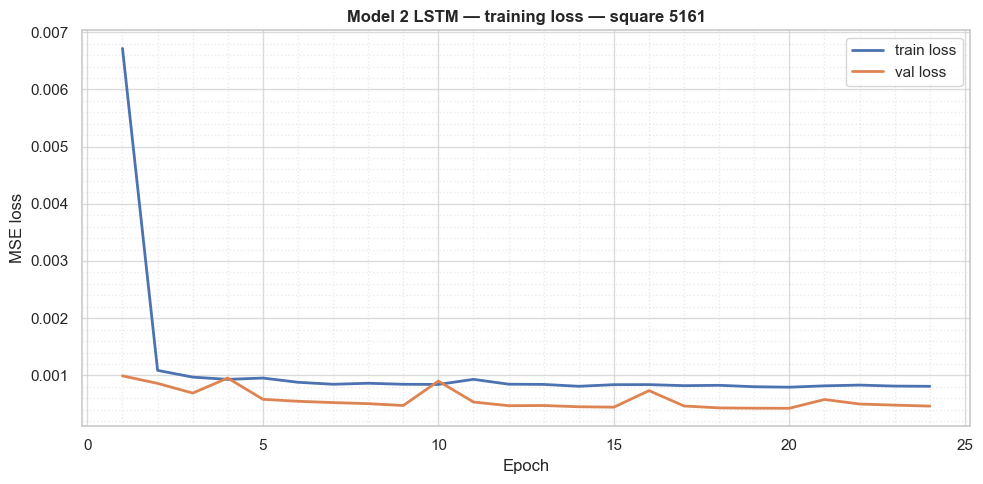

In [49]:
# Training loss vs epoch — square 5161
sid = 5161
h = m2_history[sid]
epochs_x = range(1, len(h.history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_x, h.history["loss"], label="train loss", linewidth=2)
ax.plot(epochs_x, h.history["val_loss"], label="val loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Model 2 LSTM — training loss — square %d" % sid, fontweight="bold")
ax.legend()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.minorticks_on()
plt.tight_layout()
plt.show()


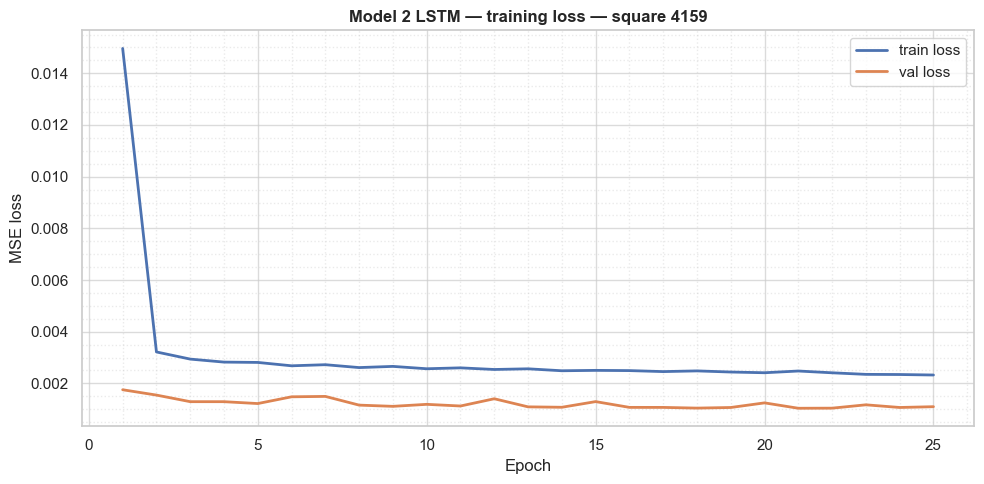

In [54]:
# Training loss vs epoch — square 4159
sid = 4159
h = m2_history[sid]
epochs_x = range(1, len(h.history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_x, h.history["loss"], label="train loss", linewidth=2)
ax.plot(epochs_x, h.history["val_loss"], label="val loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Model 2 LSTM — training loss — square %d" % sid, fontweight="bold")
ax.legend()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.minorticks_on()
plt.tight_layout()
plt.show()

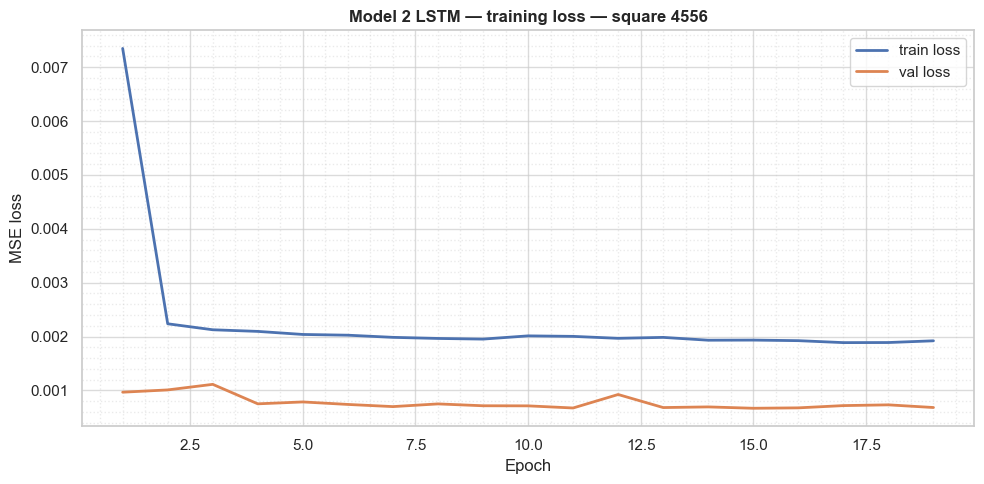

In [55]:
# Training loss vs epoch — square 4556
sid = 4556
h = m2_history[sid]
epochs_x = range(1, len(h.history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_x, h.history["loss"], label="train loss", linewidth=2)
ax.plot(epochs_x, h.history["val_loss"], label="val loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Model 2 LSTM — training loss — square %d" % sid, fontweight="bold")
ax.legend()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.minorticks_on()
plt.tight_layout()
plt.show()

In [50]:
# grid lines across the chart
def plot_lstm_forecast(sid, t_idx, y_true, y_pred):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t_idx, y_true, color="#1f77b4", label="Actual", linewidth=1.5)
    ax.plot(
        t_idx,
        y_pred,
        color="#ff7f0e",
        linestyle="--",
        label="LSTM forecast",
        linewidth=1.5,
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Internet traffic")
    ax.set_title(
        "Model 2 LSTM — Square %d — Test week 16-22 Dec 2013" % sid,
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(loc="upper right")
    ax.grid(True, which="major", linestyle="-", alpha=0.75)
    ax.grid(True, which="minor", linestyle=":", alpha=0.45)
    ax.minorticks_on()
    plt.tight_layout()
    plt.show()


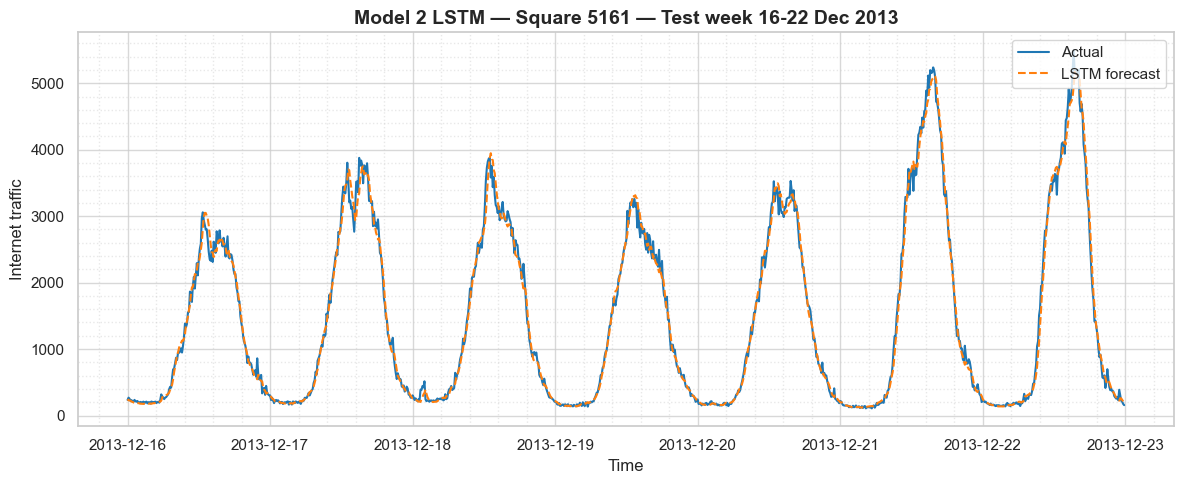

In [51]:
# Forecast plot — square 5161
sid = 5161
t_idx, y_true, y_pred = m2_preds[sid]
plot_lstm_forecast(sid, t_idx, y_true, y_pred)


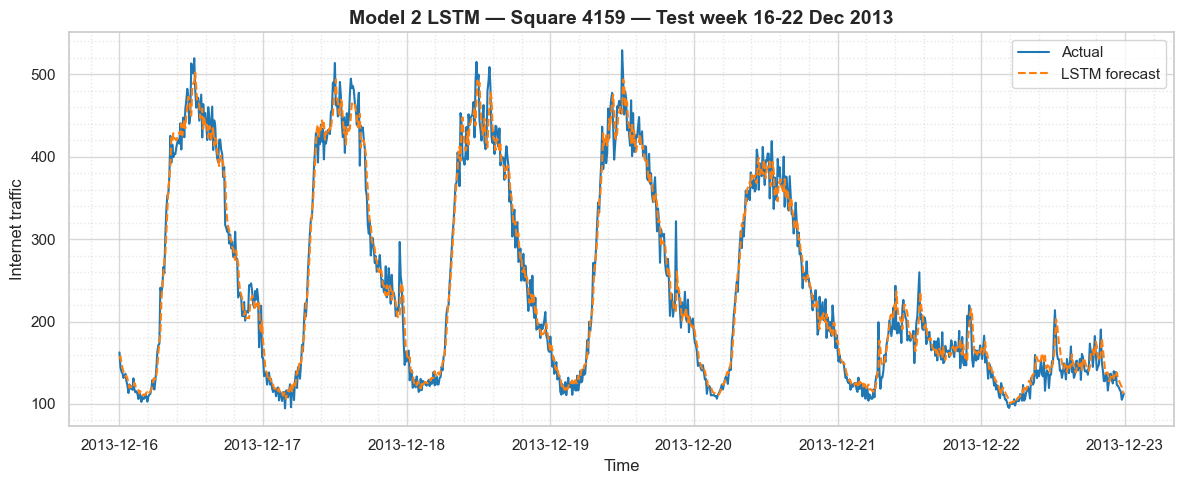

In [52]:
# Forecast plot — square 4159
sid = 4159
t_idx, y_true, y_pred = m2_preds[sid]
plot_lstm_forecast(sid, t_idx, y_true, y_pred)


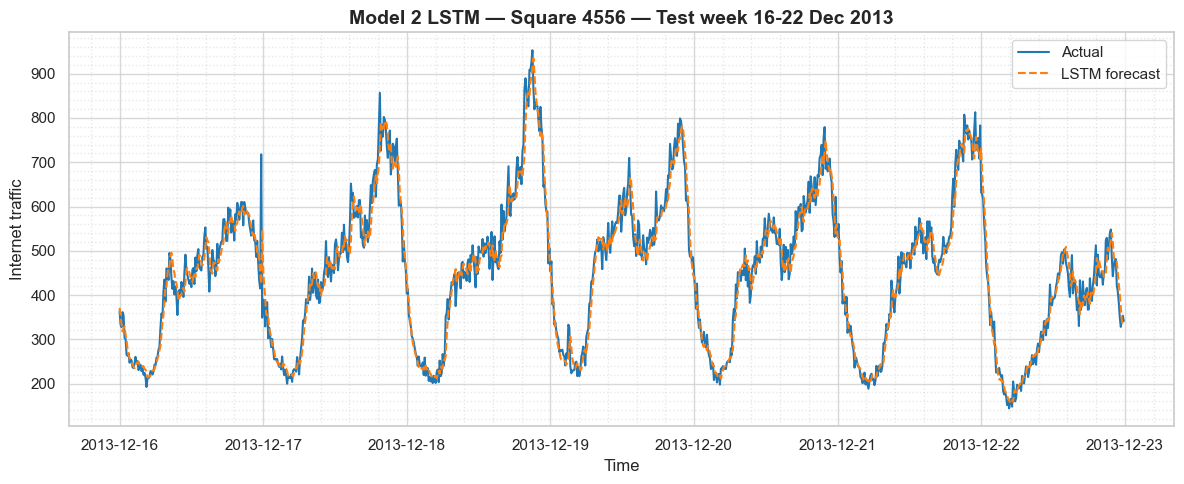

In [53]:
# Forecast plot — square 4556
sid = 4556
t_idx, y_true, y_pred = m2_preds[sid]
plot_lstm_forecast(sid, t_idx, y_true, y_pred)


### Model 3 — Gated Recurrent Unit (GRU)

In [2]:
# settings and variables to use later
LOOKBACK = 144
EPOCHS = 30
BATCH = 64
PATIENCE = 4

print("=" * 50)
print("MODEL 3 — GRU SETTINGS")
print("=" * 50)
print("lookback steps:", LOOKBACK)
print("max epochs:", EPOCHS)
print("batch size:", BATCH)
print("early-stop patience:", PATIENCE)
print("=" * 50)


MODEL 3 — GRU SETTINGS
lookback steps: 144
max epochs: 30
batch size: 64
early-stop patience: 4


In [ ]:
# libraries
from tensorflow.keras.layers import Dense, GRU, Input


In [43]:
# Data helpers for Model 3
FORECAST_SQUARES = [5161, 4159, 4556]
TEST_START = pd.Timestamp("2013-12-16")
TEST_END = pd.Timestamp("2013-12-23")


def get_regular_series(square_id):
    path = PROCESSED / f"ts_full_square_{square_id}.csv"
    if not path.is_file():
        print("building full series for square", square_id)
        df = build_ts_for_squares([square_id], tele_files)
        df.to_csv(path, index=False)
    df = pd.read_csv(path, parse_dates=["time"])
    s = df.set_index("time")["internet"].astype(float)
    s = s.resample("10min").sum().fillna(0)
    return s.sort_index()


def split_train_test(s):
    train = s[s.index < TEST_START]
    test = s[(s.index >= TEST_START) & (s.index < TEST_END)]
    return train, test


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))



In [45]:
# make_gru_xy model
def make_gru_xy(scaled_1d, lookback):
    X, y = [], []
    for i in range(lookback, len(scaled_1d)):
        X.append(scaled_1d[i - lookback : i])
        y.append(scaled_1d[i])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y

print("=" * 50)
print("make_gru_xy defined")
print("=" * 50)


make_gru_xy defined


In [46]:
#  scale the data
def scale_train_series_gru(train_series):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(
        train_series.values.reshape(-1, 1)
    ).flatten()
    return scaler, scaled

print("=" * 50)
print("scale_train_series_gru defined")
print("=" * 50)


scale_train_series_gru defined


In [47]:
#  build GRU model
def build_gru_model():
    model = Sequential(
        [
            Input(shape=(LOOKBACK, 1)),
            GRU(64),
            Dense(32, activation="relu"),
            Dense(1),
        ]
    )
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

print("=" * 50)
print("STEP 4 — GRU ARCHITECTURE (max epochs = %d)" % EPOCHS)
print("=" * 50)
build_gru_model().summary()
print("=" * 50)


STEP 4 — GRU ARCHITECTURE (max epochs = 30)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Data shape check — square 5161
s_chk = get_regular_series(5161)
tr_chk, te_chk = split_train_test(s_chk)
sc_chk, tr_sc = scale_train_series_gru(tr_chk)
X_chk, y_chk = make_gru_xy(tr_sc, LOOKBACK)

print("=" * 50)
print("DATA CHECK")
print("=" * 50)
print("train length:", len(tr_chk))
print("test length:", len(te_chk))
print("X shape:", X_chk.shape)
print("y shape:", y_chk.shape)
print("=" * 50)


DATA CHECK
train length: 6486
test length: 1008
X shape: (6342, 144, 1)
y shape: (6342,)


In [49]:
# Step 5 — train_gru
def train_gru(X_train, y_train):
    model = build_gru_model()
    early = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    )
    print("=" * 50)
    print("TRAINING — Epoch 1/%d, 2/%d, ..." % (EPOCHS, EPOCHS))
    print("=" * 50)
    t0 = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=[early],
        verbose=1,
    )
    train_sec = time.perf_counter() - t0
    epochs_run = len(history.history["loss"])
    print("=" * 50)
    print("epochs completed:", epochs_run)
    print("time (s):", round(train_sec, 2))
    print("=" * 50)
    return model, history, train_sec, epochs_run

print("train_gru defined")


train_gru defined


In [50]:
# predict_gru_test
def predict_gru_test(model, train, test, scaler, lookback):
    train_s = scaler.transform(train.values.reshape(-1, 1)).flatten()
    test_s = scaler.transform(test.values.reshape(-1, 1)).flatten()
    history = list(train_s[-lookback:])
    preds_scaled = []
    for i in range(len(test)):
        window = np.array(history[-lookback:]).reshape(1, lookback, 1)
        p = model.predict(window, verbose=0)[0, 0]
        preds_scaled.append(p)
        history.append(test_s[i])
    preds = scaler.inverse_transform(
        np.array(preds_scaled).reshape(-1, 1)
    ).flatten()
    return preds

print("predict_gru_test defined")


predict_gru_test defined


In [52]:
# storage
m3_preds = {}
m3_metrics = {}
m3_train_sec = {}
m3_predict_sec = {}
m3_epochs_run = {}
m3_history = {}
print("READY for squares 5161, 4159, 4556")


READY for squares 5161, 4159, 4556


In [53]:
# Square 5161
sid = 5161
print("\n" + "=" * 50)
print("SQUARE", sid)
print("=" * 50)
s = get_regular_series(sid)
train, test = split_train_test(s)
scaler, tr_sc = scale_train_series_gru(train)
X_tr, y_tr = make_gru_xy(tr_sc, LOOKBACK)
model, hist, t_train, n_ep = train_gru(X_tr, y_tr)
m3_train_sec[sid] = t_train
m3_epochs_run[sid] = n_ep
m3_history[sid] = hist
t0 = time.perf_counter()
pred = predict_gru_test(model, train, test, scaler, LOOKBACK)
m3_predict_sec[sid] = time.perf_counter() - t0
y_true = test.values
m3_preds[sid] = (test.index, y_true, pred)
m3_metrics[sid] = {
    "MAE": mae(y_true, pred),
    "MAPE": mape(y_true, pred),
    "RMSE": rmse(y_true, pred),
}
print("metrics:", m3_metrics[sid])
print("epochs:", n_ep, "| train(s):", round(t_train, 2), "| pred(s):", round(m3_predict_sec[sid], 2))



SQUARE 5161
TRAINING — Epoch 1/30, 2/30, ...
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0071 - mae: 0.0481 - val_loss: 8.4322e-04 - val_mae: 0.0209
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 9.6174e-04 - mae: 0.0207 - val_loss: 4.9978e-04 - val_mae: 0.0154
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 8.7572e-04 - mae: 0.0194 - val_loss: 4.3970e-04 - val_mae: 0.0149
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 8.7840e-04 - mae: 0.0194 - val_loss: 5.0337e-04 - val_mae: 0.0174
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 8.8906e-04 - mae: 0.0200 - val_loss: 4.5019e-04 - val_mae: 0.0145
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 8.5042e-04 - mae: 0.0189 - val_loss: 5.7418e-04 - val_mae: 0.0164
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 8.8260e-04 - mae: 0.0196 - val_loss: 4.7929e-04 - val_mae: 0.0153
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.


In [54]:
# Square 4159
sid = 4159
print("\n" + "=" * 50)
print("SQUARE", sid)
print("=" * 50)
s = get_regular_series(sid)
train, test = split_train_test(s)
scaler, tr_sc = scale_train_series_gru(train)
X_tr, y_tr = make_gru_xy(tr_sc, LOOKBACK)
model, hist, t_train, n_ep = train_gru(X_tr, y_tr)
m3_train_sec[sid] = t_train
m3_epochs_run[sid] = n_ep
m3_history[sid] = hist
t0 = time.perf_counter()
pred = predict_gru_test(model, train, test, scaler, LOOKBACK)
m3_predict_sec[sid] = time.perf_counter() - t0
y_true = test.values
m3_preds[sid] = (test.index, y_true, pred)
m3_metrics[sid] = {
    "MAE": mae(y_true, pred),
    "MAPE": mape(y_true, pred),
    "RMSE": rmse(y_true, pred),
}
print("metrics:", m3_metrics[sid])



SQUARE 4159
TRAINING — Epoch 1/30, 2/30, ...
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0078 - mae: 0.0552 - val_loss: 0.0012 - val_mae: 0.0236
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0028 - mae: 0.0360 - val_loss: 0.0012 - val_mae: 0.0231
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0027 - mae: 0.0352 - val_loss: 0.0011 - val_mae: 0.0228
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0027 - mae: 0.0351 - val_loss: 0.0012 - val_mae: 0.0244
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0026 - mae: 0.0345 - val_loss: 0.0011 - val_mae: 0.0224
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0027 - mae: 0.0351 - val_loss: 0.0011 - val_mae: 0.0228
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0026 - mae: 0.0347 - val_loss: 0.0012 - val_mae: 0.0230
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0026 - mae: 0.0345 - val_loss: 0.0013 - val_mae: 0.0269
Epoch 9/30
90/90 ━

In [55]:
# Square 4556
sid = 4556
print("\n" + "=" * 50)
print("SQUARE", sid)
print("=" * 50)
s = get_regular_series(sid)
train, test = split_train_test(s)
scaler, tr_sc = scale_train_series_gru(train)
X_tr, y_tr = make_gru_xy(tr_sc, LOOKBACK)
model, hist, t_train, n_ep = train_gru(X_tr, y_tr)
m3_train_sec[sid] = t_train
m3_epochs_run[sid] = n_ep
m3_history[sid] = hist
t0 = time.perf_counter()
pred = predict_gru_test(model, train, test, scaler, LOOKBACK)
m3_predict_sec[sid] = time.perf_counter() - t0
y_true = test.values
m3_preds[sid] = (test.index, y_true, pred)
m3_metrics[sid] = {
    "MAE": mae(y_true, pred),
    "MAPE": mape(y_true, pred),
    "RMSE": rmse(y_true, pred),
}
print("metrics:", m3_metrics[sid])



SQUARE 4556
TRAINING — Epoch 1/30, 2/30, ...
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0080 - mae: 0.0575 - val_loss: 9.5566e-04 - val_mae: 0.0237
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0021 - mae: 0.0326 - val_loss: 8.8377e-04 - val_mae: 0.0233
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0021 - mae: 0.0323 - val_loss: 0.0010 - val_mae: 0.0254
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0020 - mae: 0.0318 - val_loss: 7.9409e-04 - val_mae: 0.0213
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0020 - mae: 0.0314 - val_loss: 6.8028e-04 - val_mae: 0.0196
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0020 - mae: 0.0312 - val_loss: 6.6169e-04 - val_mae: 0.0195
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0019 - mae: 0.0309 - val_loss: 6.6835e-04 - val_mae: 0.0196
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0020 - mae: 0.0312 - val_loss: 6.9721e-04 - val_ma

In [58]:
# summary
print("\n" + "=" * 80)
print("MODEL 3 — FINAL SUMMARY")
print("=" * 80)
print(f"{'Square':<8} {'MAE':>10} {'MAPE':>10} {'RMSE':>10} {'Epochs':>8} {'Train_s':>10} {'Pred_s':>10}")
print("-" * 80)
for sid in FORECAST_SQUARES:
    m = m3_metrics[sid]
    print(
        f"{sid:<8} {m['MAE']:>10.2f} {m['MAPE']:>10.2f} {m['RMSE']:>10.2f} "
        f"{m3_epochs_run[sid]:>8} {m3_train_sec[sid]:>10.2f} {m3_predict_sec[sid]:>10.2f}"
    )
print("=" * 80)



MODEL 3 — FINAL SUMMARY
Square          MAE       MAPE       RMSE   Epochs    Train_s     Pred_s
--------------------------------------------------------------------------------
5161          94.99      13.56     130.30        7      34.11      85.09
4159          14.80       6.51      20.08       15      90.42      85.43
4556          26.84       6.20      36.01       13      62.26      83.24


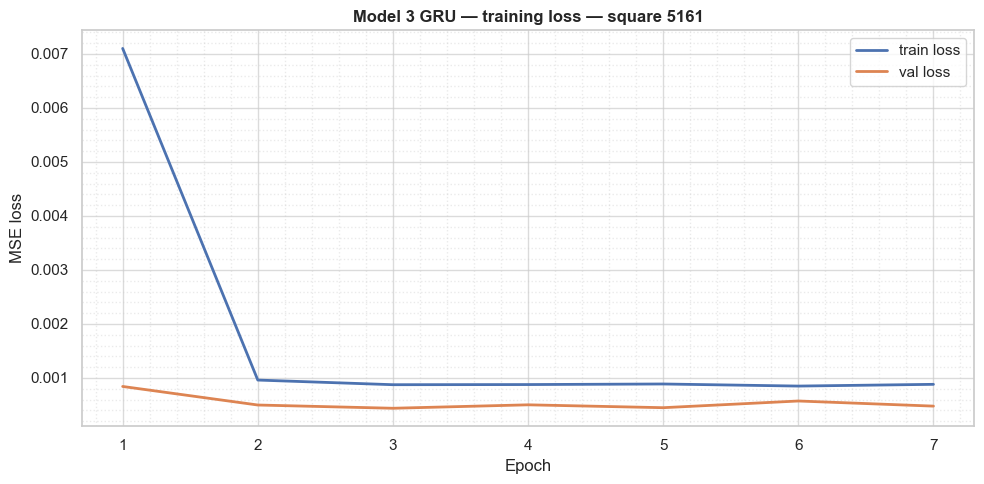

In [59]:
# Training loss — square 5161
sid = 5161
h = m3_history[sid]
ex = range(1, len(h.history["loss"]) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ex, h.history["loss"], label="train loss", linewidth=2)
ax.plot(ex, h.history["val_loss"], label="val loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Model 3 GRU — training loss — square %d" % sid, fontweight="bold")
ax.legend()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.minorticks_on()
plt.tight_layout()
plt.show()


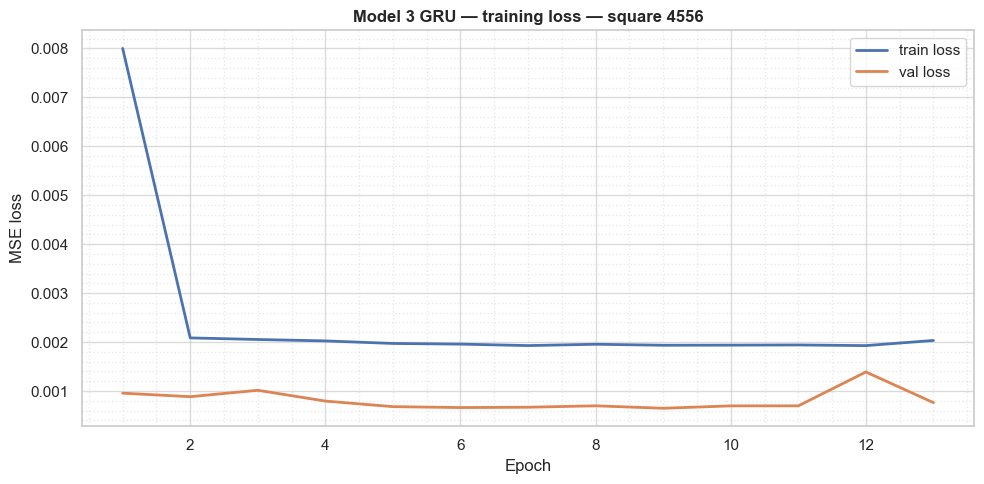

In [60]:
# Training loss — square 4556
sid = 4556
h = m3_history[sid]
ex = range(1, len(h.history["loss"]) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ex, h.history["loss"], label="train loss", linewidth=2)
ax.plot(ex, h.history["val_loss"], label="val loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Model 3 GRU — training loss — square %d" % sid, fontweight="bold")
ax.legend()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.minorticks_on()
plt.tight_layout()
plt.show()

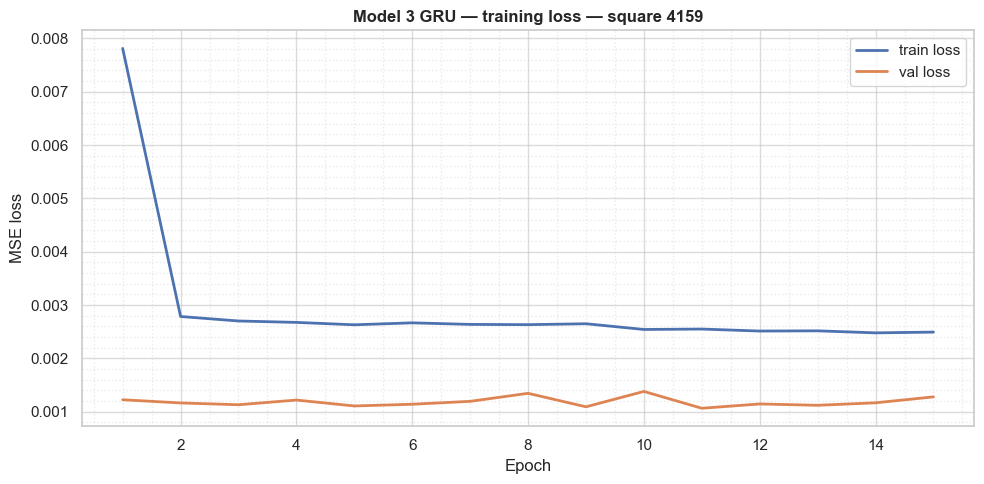

In [61]:
# Training loss — square 4159 
sid = 4159 
h = m3_history[sid]
ex = range(1, len(h.history["loss"]) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ex, h.history["loss"], label="train loss", linewidth=2)
ax.plot(ex, h.history["val_loss"], label="val loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Model 3 GRU — training loss — square %d" % sid, fontweight="bold")
ax.legend()
ax.grid(True, which="major", linestyle="-", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)
ax.minorticks_on()
plt.tight_layout()
plt.show()

In [62]:
# Forecast plot helper
def plot_gru_forecast(sid, t_idx, y_true, y_pred):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t_idx, y_true, color="#2ca02c", label="Actual", linewidth=1.5)
    ax.plot(
        t_idx, y_pred,
        color="#d62728", linestyle="--", label="GRU forecast", linewidth=1.5,
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Internet traffic")
    ax.set_title(
        "Model 3 GRU — Square %d — Test week 16-22 Dec 2013" % sid,
        fontsize=14, fontweight="bold",
    )
    ax.legend(loc="upper right")
    ax.grid(True, which="major", linestyle="-", alpha=0.75)
    ax.grid(True, which="minor", linestyle=":", alpha=0.45)
    ax.minorticks_on()
    plt.tight_layout()
    plt.show()


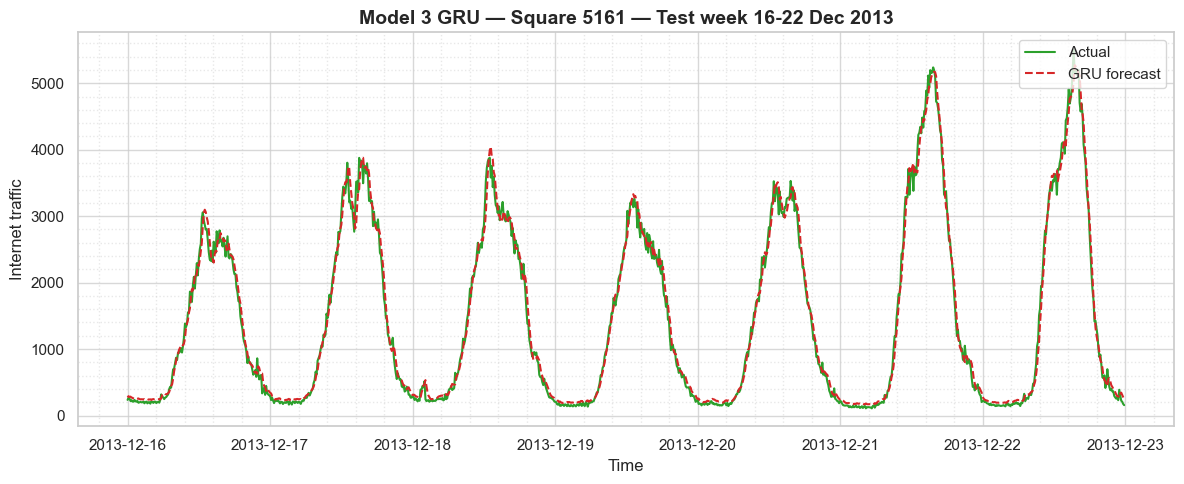

In [63]:
# Forecast — 5161
sid = 5161
plot_gru_forecast(sid, *m3_preds[sid])


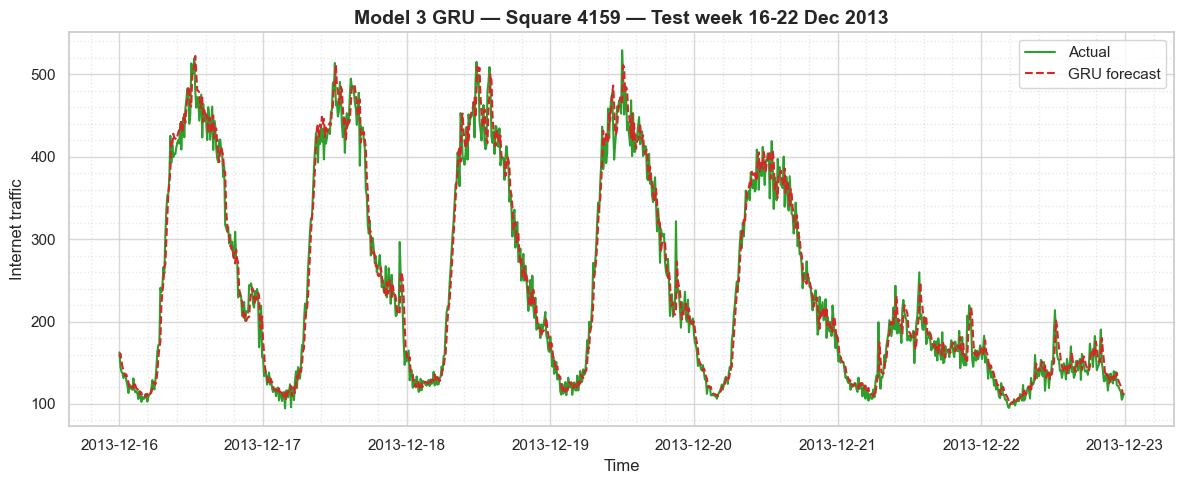

In [64]:
# Forecast — 4159
sid = 4159
plot_gru_forecast(sid, *m3_preds[sid])


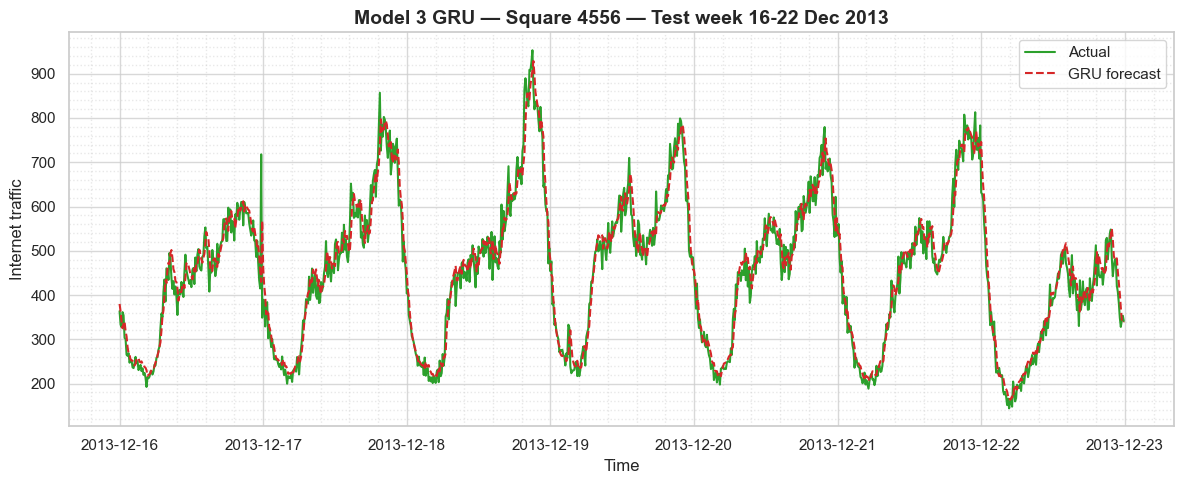

In [65]:
# Forecast — 4556
sid = 4556
plot_gru_forecast(sid, *m3_preds[sid])


In [77]:
# Compare Model 1, 2, 3
print("\n" + "=" * 50)
print("ALL MODELS — METRICS")
print("=" * 50)
for sid in FORECAST_SQUARES:
    print("Square", sid)
    for label, d in [("M1 OLS", m1_metrics), ("M2 LSTM", m2_metrics), ("M3 GRU", m3_metrics)]:
        m = d[sid]
        print(f"  {label}: MAE={m['MAE']:.2f} MAPE={m['MAPE']:.2f} RMSE={m['RMSE']:.2f}")
print("=" * 50)



ALL MODELS — METRICS
Square 5161
  M1 OLS: MAE=140.48 MAPE=13.82 RMSE=199.81
  M2 LSTM: MAE=86.40 MAPE=9.89 RMSE=127.73
  M3 GRU: MAE=94.99 MAPE=13.56 RMSE=130.30
Square 4159
  M1 OLS: MAE=18.79 MAPE=8.29 RMSE=25.10
  M2 LSTM: MAE=14.30 MAPE=6.32 RMSE=19.42
  M3 GRU: MAE=14.80 MAPE=6.51 RMSE=20.08
Square 4556
  M1 OLS: MAE=33.66 MAPE=8.02 RMSE=43.97
  M2 LSTM: MAE=28.07 MAPE=6.42 RMSE=37.52
  M3 GRU: MAE=26.84 MAPE=6.20 RMSE=36.01
